In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
from tqdm import tqdm
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy as np
from scipy.spatial import cKDTree

def mymap():
        
    fig = plt.figure(figsize=(11,8.5))
    ax=plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines(resolution='110m',zorder=11,linewidth=.1)
    ax.add_feature(cfeature.LAND,color='lightgrey',zorder=10)
    
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xlocator = mticker.MaxNLocator(6)
    gl.ylocator = mticker.MaxNLocator(6)

    return fig,ax

In [4]:
#temp = xr.concat([temp20,temp21,temp22,temp23],dim='Time').isel(nv=0,st_ocean=0,st_edges_ocean=0)

# open backtrack

## this is the wrong cell but i'm just tryingn sth ok

In [4]:
path_gaby = '/srv/scratch/oceanopen/GlobalBlueBottles/VarDriftExp/VarDriftExpHanded/'

files_gaby_all = glob.glob(path_gaby+'*_VarWindDrift.nc')

print(len(files_gaby_all))

files_gaby = []
for i in range(len(files_gaby_all)):
    f = xr.open_dataset(files_gaby_all[i])
    
    if len(f['time'])>360:
        files_gaby.append(files_gaby_all[i])

files_gaby = np.array(files_gaby)

print(len(files_gaby))

91
84


In [40]:
left = 0
right = 0
for f in files_gaby:
    if f[-18] == 'f':
        left +=1
    elif f[-18] == 'h':
        right+=1

print(left)
print(right)
print(left+right)

55
29
84


In [2]:
path_gaby_hands = '/srv/scratch/oceanopen/GlobalBlueBottles/VarDrift2hands/'

files_gaby_all_left = glob.glob(path_gaby_hands+'S.*.folderL/*.nc')
files_gaby_all_right = glob.glob(path_gaby_hands+'S.*.folderR/*.nc')

print(len(files_gaby_all_right))

files_gaby_left = []
files_gaby_right = []

for i in tqdm(range(len(files_gaby_all_right))):
    fR = xr.open_dataset(files_gaby_all_right[i])
    fL = xr.open_dataset(files_gaby_all_left[i])
    
    if len(fR['time'])>360:
        files_gaby_right.append(files_gaby_all_right[i])

    if len(fL['time'])>360:
        files_gaby_left.append(files_gaby_all_left[i])

files_gaby_right = np.array(files_gaby_right)
files_gaby_left = np.array(files_gaby_left)

print(len(files_gaby_right))
print(len(files_gaby_left))

66


100%|██████████| 66/66 [00:27<00:00,  2.38it/s]

52
52


In [102]:
len(years_samples[years_samples==2023])/len(years_samples)

0.4171779141104294

In [94]:
years_samples = np.array([d.year for d in pd.to_datetime(lineage['date_collected'])])

/scratch/pbs.6614217.kman.restech.unsw.edu.au/ipykernel_1101656/963506452.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  years_samples = np.array([d.year for d in pd.to_datetime(lineage['date_collected'])])


In [5]:
import re

samples_gaby = [int(re.search(r'/(\d+)s_', path).group(1)) for path in files_gaby]
samples_gaby_right = [int(re.search(r'S\.(\d+)\.folder', path).group(1)) for path in files_gaby_right]
samples_gaby_left = [int(re.search(r'S\.(\d+)\.folder', path).group(1)) for path in files_gaby_left]

lineage = pd.read_csv('/srv/scratch/oceanopen/GlobalBlueBottles/SHC_Physalia_lineage_assignments_Nov2024.csv')

print(samples_gaby)

[132, 6, 12, 114, 141, 21, 51, 42, 60, 56, 92, 29, 83, 95, 59, 86, 136, 109, 127, 73, 82, 7, 11, 50, 107, 35, 71, 53, 17, 80, 113, 94, 85, 67, 79, 138, 54, 90, 129, 27, 75, 93, 84, 31, 40, 89, 1, 112, 10, 130, 142, 52, 16, 70, 34, 25, 66, 57, 78, 156, 87, 62, 26, 137, 128, 74, 161, 88, 111, 135, 126, 108, 72, 81, 28, 139, 91, 58, 76, 110, 104, 140, 20, 5]


In [9]:
def get_lonlat(f):

    
    diff_data_lon = f['lon'].diff(dim="time")
    diff_data_lat = f['lat'].diff(dim="time")
    
    zeros = np.logical_and(diff_data_lon == 0, diff_data_lat == 0).values
    
    pattern = np.lib.stride_tricks.sliding_window_view(zeros, window_shape=3, axis=1)
    beached_mask = np.all(pattern, axis=2)

    has_beached_before_end = beached_mask.any(axis=1)    
    traj_indices = np.where(has_beached_before_end)[0]
    time_indices = zeros[traj_indices, :-1].argmax(axis=1)
    
    lon = f['lon'].values
    lat = f['lat'].values
    lon[np.abs(lon)>1e4]=np.nan
    lat[np.abs(lat)>1e4]=np.nan

    
    for j in range(len(traj_indices)):
        lon[traj_indices[j], time_indices[j]:]=np.nan
        lat[traj_indices[j], time_indices[j]:]=np.nan

    return lon,lat, np.tile(f['time'].values, (lon.shape[0], 1))



def get_lonlat_hand(f_ori):

    f = f_ori.isel(trajectory = np.arange(0,1000,2))
    
    
    diff_data_lon = f['lon'].diff(dim="time")
    diff_data_lat = f['lat'].diff(dim="time")
    
    zeros = np.logical_and(diff_data_lon == 0, diff_data_lat == 0).values
    
    pattern = np.lib.stride_tricks.sliding_window_view(zeros, window_shape=3, axis=1)
    beached_mask = np.all(pattern, axis=2)

    has_beached_before_end = beached_mask.any(axis=1)    
    traj_indices = np.where(has_beached_before_end)[0]
    time_indices = zeros[traj_indices, :-1].argmax(axis=1)
    
    lon = f['lon'].values
    lat = f['lat'].values
    lon[np.abs(lon)>1e4]=np.nan
    lat[np.abs(lat)>1e4]=np.nan

    
    for j in range(len(traj_indices)):
        lon[traj_indices[j], time_indices[j]:]=np.nan
        lat[traj_indices[j], time_indices[j]:]=np.nan

    return lon,lat, np.tile(f['time'].values, (lon.shape[0], 1))


In [10]:
def get_lineage_positions(mylin):
    print(mylin)
    lons, lats, times = [], [], []
    for i in range(len(files_gaby)):
    
        lin = lineage['lineage'].values[samples_gaby[i]-1]
        if lin == mylin:
            lonA, latA, timeA = get_lonlat(xr.open_dataset(files_gaby[i]))
            lons.append(lonA)
            lats.append(latA)
            times.append(timeA)
            
    for i in range(len(files_gaby_right)):
        lin = lineage['lineage'].values[samples_gaby_right[i]-1]
        if lin == mylin:
            lonR, latR, timeR = get_lonlat_hand(xr.open_dataset(files_gaby_right[i]))
            lons.append(lonR)
            lats.append(latR)
            times.append(timeR)
    
    for i in range(len(files_gaby_left)):
        lin = lineage['lineage'].values[samples_gaby_left[i]-1]
        if lin == mylin:    
            lonL, latL, timeL = get_lonlat_hand(xr.open_dataset(files_gaby_left[i]))
            lons.append(lonL)
            lats.append(latL)
            times.append(timeL)
    
    print('opening done')
    
    lons_lin = np.concatenate(lons)
    lats_lin = np.concatenate(lats)
    times_lin = np.concatenate(times)

    lons_all_lin = np.concatenate(lons_lin)
    lats_all_lin = np.concatenate(lats_lin)
    times_all_lin = np.concatenate(times_lin)

    times_all_lin = times_all_lin[~np.isnan(lons_all_lin)]
    lons_all_lin = lons_all_lin[~np.isnan(lons_all_lin)]
    lats_all_lin = lats_all_lin[~np.isnan(lats_all_lin)]
    
    return lons_all_lin, lats_all_lin, times_all_lin

In [11]:
lons_A, lats_A, times_A = get_lineage_positions("A")
lons_B1, lats_B1, times_B1 = get_lineage_positions("B1")
lons_B2, lats_B2, times_B2 = get_lineage_positions("B2")
lons_C1, lats_C1, times_C1 = get_lineage_positions("C1")
lons_C2, lats_C2, times_C2 = get_lineage_positions("C2")


A
opening done
B1
opening done
B2
opening done
C1
opening done
C2
opening done


In [12]:
months = pd.to_datetime(times_A).month
len(months[np.isin(months,[1,3,5])])

1939446

DJF 25. MAM 24. JJA 24. SON 24.
DJF 24. MAM 25. JJA 24. SON 24.
DJF 22. MAM 35. JJA 21. SON 20.
DJF 23. MAM 27. JJA 25. SON 23.
DJF 30. MAM 21. JJA 22. SON 25.


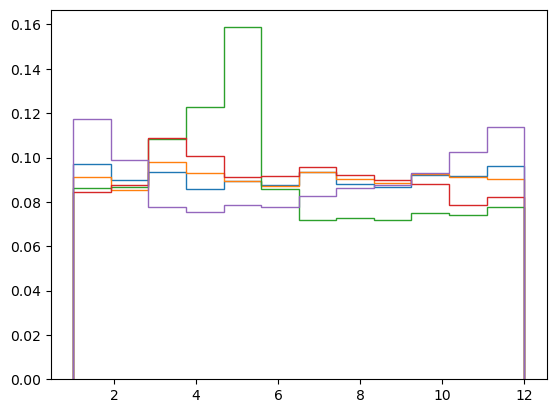

In [13]:
fig,ax=plt.subplots()

for t in [times_A, times_B1, times_B2, times_C1, times_C2]:
    
    months = pd.to_datetime(t).month
    h = ax.hist(months, bins=12, density=True, histtype='step')

    all_len = len(months)
    
    perc_djf = len(months[np.isin(months,[12,1,2])])/all_len
    perc_mam = len(months[np.isin(months,[3,4,5])])/all_len
    perc_jja = len(months[np.isin(months,[6,7,8])])/all_len
    perc_son = len(months[np.isin(months,[9,10,11])])/all_len

    print('DJF', str(100*perc_djf)[:3], 'MAM', str(100*perc_mam)[:3], 'JJA', str(100*perc_jja)[:3],'SON', str(100*perc_son)[:3])
    

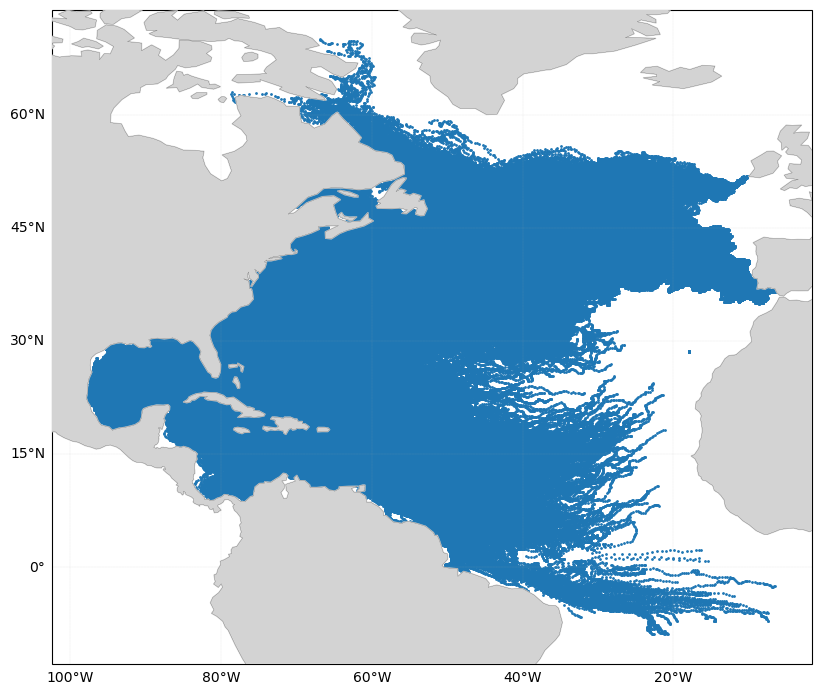

In [10]:
fig, ax = mymap()
ax.scatter(lons_A,lats_A,s=1)

In [11]:
pd.to_datetime(lineage['date_collected'][0])

/scratch/pbs.6544682.kman.restech.unsw.edu.au/ipykernel_37966/2574883839.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pd.to_datetime(lineage['date_collected'][0])


Timestamp('2023-05-14 00:00:00')

In [14]:
def sample_info(thelineage):
    lons, lats, times = [], [], []
    for i in range(len(files_gaby)):
    
        lin = lineage['lineage'].values[samples_gaby[i]-1]

        if lin == thelineage:
            lons.append(lineage['longitue'].values[samples_gaby[i]-1])
            lats.append(lineage['latitude'].values[samples_gaby[i]-1])
            times.append(pd.to_datetime(lineage['date_collected'].values[samples_gaby[i]-1]))
            
    for i in range(len(files_gaby_right)):

        lin = lineage['lineage'].values[samples_gaby_right[i]-1]

        if lin == thelineage:
            lons.append(lineage['longitue'].values[samples_gaby_right[i]-1])
            lats.append(lineage['latitude'].values[samples_gaby_right[i]-1])
            times.append(pd.to_datetime(lineage['date_collected'].values[samples_gaby_right[i]-1]))

    
    for i in range(len(files_gaby_left)):

        lin = lineage['lineage'].values[samples_gaby_left[i]-1]

        if lin == thelineage:
            lons.append(lineage['longitue'].values[samples_gaby_left[i]-1])
            lats.append(lineage['latitude'].values[samples_gaby_left[i]-1])
            times.append(pd.to_datetime(lineage['date_collected'].values[samples_gaby_left[i]-1]))

    return np.array(lons), np.array(lats), np.array(times).astype('datetime64[ns]')

In [15]:
lons_S_A, lats_S_A, times_S_A = sample_info("A")
lons_S_B1, lats_S_B1, times_S_B1 = sample_info("B1")
lons_S_B2, lats_S_B2, times_S_B2 = sample_info("B2")
lons_S_C1, lats_S_C1, times_S_C1 = sample_info("C1")
lons_S_C2, lats_S_C2, times_S_C2 = sample_info("C2")


/scratch/pbs.6614217.kman.restech.unsw.edu.au/ipykernel_1101656/1841046774.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  times.append(pd.to_datetime(lineage['date_collected'].values[samples_gaby[i]-1]))
/scratch/pbs.6614217.kman.restech.unsw.edu.au/ipykernel_1101656/1841046774.py:19: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  times.append(pd.to_datetime(lineage['date_collected'].values[samples_gaby_right[i]-1]))
/scratch/pbs.6614217.kman.restech.unsw.edu.au/ipykernel_1101656/1841046774.py:29: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  times.append(pd.to_datetime(lineage['date_collected'].values[samples_gaby_left[i]-1]))


DJF 17. MAM 31. JJA 31. SON 20.
DJF 16. MAM 25. JJA 19. SON 39.
DJF 0.0 MAM 33. JJA 22. SON 44.
DJF 12. MAM 43. JJA 12. SON 31.
DJF 100 MAM 0.0 JJA 0.0 SON 0.0


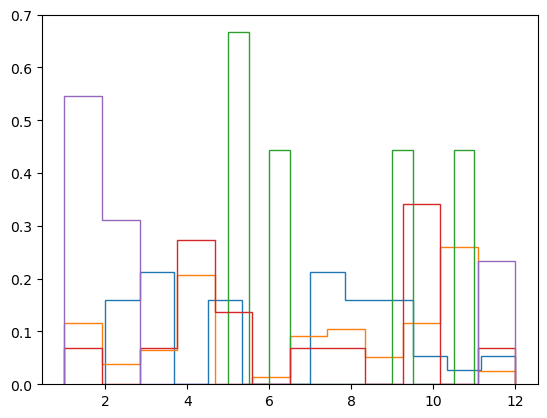

In [16]:
fig,ax=plt.subplots()

for t in [times_S_A, times_S_B1, times_S_B2, times_S_C1, times_S_C2]:

    months = pd.to_datetime(t).month
    h = ax.hist(months, bins=12, density=True, histtype='step')

    all_len = len(months)
    
    perc_djf = len(months[np.isin(months,[12,1,2])])/all_len
    perc_mam = len(months[np.isin(months,[3,4,5])])/all_len
    perc_jja = len(months[np.isin(months,[6,7,8])])/all_len
    perc_son = len(months[np.isin(months,[9,10,11])])/all_len

    print('DJF', str(100*perc_djf)[:3], 'MAM', str(100*perc_mam)[:3], 'JJA', str(100*perc_jja)[:3],'SON', str(100*perc_son)[:3])
    

In [17]:
year = 2020
month = 7
temp = xr.open_dataset('/srv/scratch/oceanopen/BRAN2020_files/ocean_temp_'+str(year)+'_'+str(month).zfill(2)+'_surf.nc',decode_timedelta=True).isel(nv=0,st_ocean=0,st_edges_ocean=0)
lon_temp, lat_temp = np.meshgrid(temp['xt_ocean'].values, temp['yt_ocean'].values)


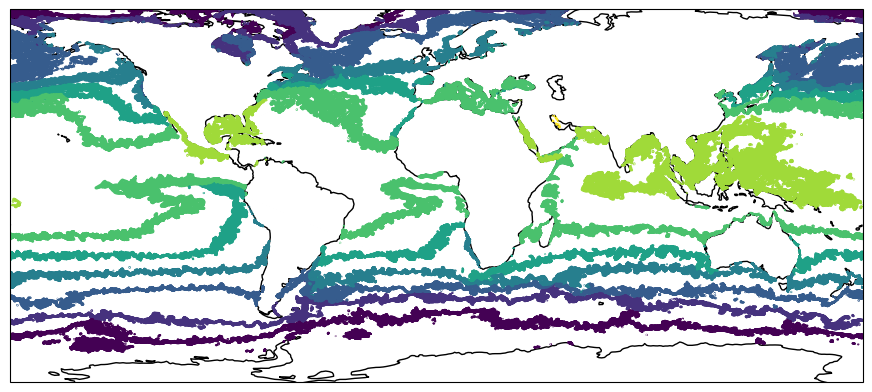

In [19]:
import cartopy.crs as ccrs
fig = plt.figure(figsize=(11,8.5))
ax=plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

for i in range(temp['temp'].shape[0]):
    ax.contour(lon_temp, lat_temp, temp['temp'][i].values,levels=[0,5,10,15,20,25,30,35])

1


/scratch/pbs.6544682.kman.restech.unsw.edu.au/ipykernel_33334/2515998736.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


2


/scratch/pbs.6544682.kman.restech.unsw.edu.au/ipykernel_33334/2515998736.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


3


...

/scratch/pbs.6544682.kman.restech.unsw.edu.au/ipykernel_33334/2515998736.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


11


/scratch/pbs.6544682.kman.restech.unsw.edu.au/ipykernel_33334/2515998736.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


12


/scratch/pbs.6544682.kman.restech.unsw.edu.au/ipykernel_33334/2515998736.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


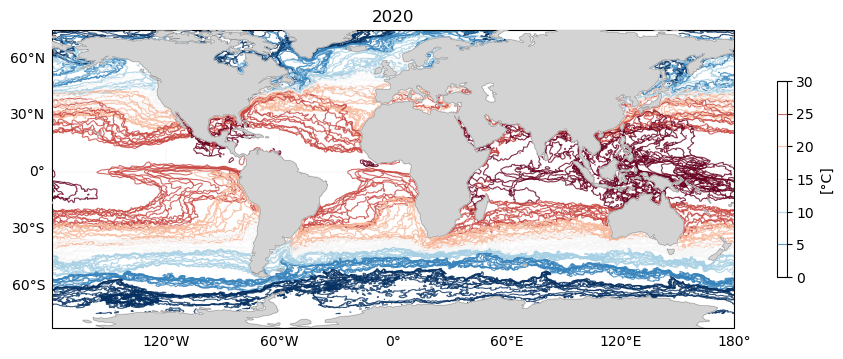

In [20]:
import cartopy.crs as ccrs
import cartopy.crs as ccrs


fig = plt.figure(figsize=(11,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines(resolution='110m',zorder=11,linewidth=.1)
ax.add_feature(cfeature.LAND,color='lightgrey',zorder=10)

gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xlocator = mticker.MaxNLocator(6)
gl.ylocator = mticker.MaxNLocator(6)
ax.set_title('2020')

year = 2020

for month in range(1,13):
    print(month)
    temp = xr.open_dataset('/srv/scratch/oceanopen/BRAN2020_files/ocean_temp_'+str(year)+'_'+str(month).zfill(2)+'_surf.nc',decode_timedelta=True).isel(nv=0,st_ocean=0,st_edges_ocean=0)
    ave_temp = np.nanmean(temp['temp'].values,axis=0)

    c=ax.contour(temp['xt_ocean'],temp['yt_ocean'],ave_temp,levels=[0,5,10,15,20,25,30],alpha=.8,linewidths=.8,cmap='RdBu_r',transform=ccrs.PlateCarree())

fig.colorbar(c,shrink=.3,label='[°C]')
fig.savefig('map_temperature_contour2020.png',dpi=500,bbox_inches='tight')

1


/scratch/pbs.6676660.kman.restech.unsw.edu.au/ipykernel_2076543/851306028.py:24: RuntimeWarning: Mean of empty slice
  ave_temp.append(np.nanmean(temp['temp'].values,axis=0))


2


/scratch/pbs.6676660.kman.restech.unsw.edu.au/ipykernel_2076543/851306028.py:24: RuntimeWarning: Mean of empty slice
  ave_temp.append(np.nanmean(temp['temp'].values,axis=0))


3


...

/scratch/pbs.6676660.kman.restech.unsw.edu.au/ipykernel_2076543/851306028.py:24: RuntimeWarning: Mean of empty slice
  ave_temp.append(np.nanmean(temp['temp'].values,axis=0))


11


/scratch/pbs.6676660.kman.restech.unsw.edu.au/ipykernel_2076543/851306028.py:24: RuntimeWarning: Mean of empty slice
  ave_temp.append(np.nanmean(temp['temp'].values,axis=0))


12


/scratch/pbs.6676660.kman.restech.unsw.edu.au/ipykernel_2076543/851306028.py:24: RuntimeWarning: Mean of empty slice
  ave_temp.append(np.nanmean(temp['temp'].values,axis=0))
/scratch/pbs.6676660.kman.restech.unsw.edu.au/ipykernel_2076543/851306028.py:26: RuntimeWarning: Mean of empty slice
  c=ax.contourf(temp['xt_ocean'],temp['yt_ocean'],np.nanmean(ave_temp,axis=0),levels=np.linspace(5,30,20), cmap='RdBu_r',transform=ccrs.PlateCarree())


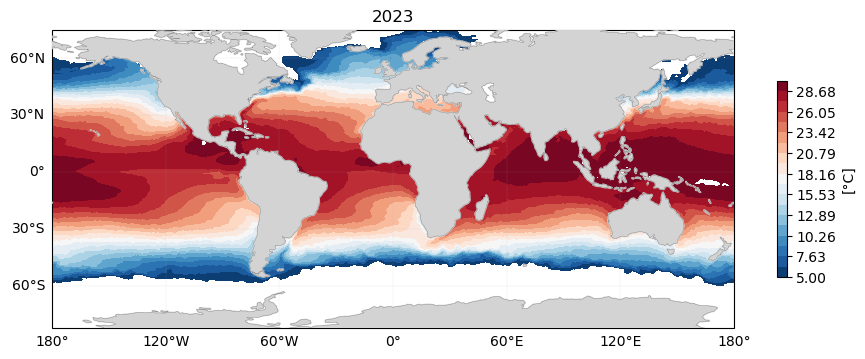

In [5]:
import cartopy.crs as ccrs
import cartopy.crs as ccrs


fig = plt.figure(figsize=(11,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines(resolution='110m',zorder=11,linewidth=.1)
ax.add_feature(cfeature.LAND,color='lightgrey',zorder=10)

gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xlocator = mticker.MaxNLocator(6)
gl.ylocator = mticker.MaxNLocator(6)
ax.set_title('2023')

year = 2023
ave_temp = []
for month in range(1,13):
    print(month)
    temp = xr.open_dataset('/srv/scratch/oceanopen/BRAN2020_files/ocean_temp_'+str(year)+'_'+str(month).zfill(2)+'_surf.nc',decode_timedelta=True).isel(nv=0,st_ocean=0,st_edges_ocean=0)
    ave_temp.append(np.nanmean(temp['temp'].values,axis=0))

c=ax.contourf(temp['xt_ocean'],temp['yt_ocean'],np.nanmean(ave_temp,axis=0),levels=np.linspace(5,30,20), cmap='RdBu_r',transform=ccrs.PlateCarree())

fig.colorbar(c,shrink=.3,label='[°C]')
fig.savefig('map_temperature_ave_all2023.png',dpi=500,bbox_inches='tight')

In [4]:
np.savez('ave_sstglobal_2023.npz',lon = temp['xt_ocean'], lat=temp['yt_ocean'],stat = np.nanmean(ave_temp,axis=0))

/scratch/pbs.6676660.kman.restech.unsw.edu.au/ipykernel_2076543/787525663.py:1: RuntimeWarning: Mean of empty slice
  np.savez('ave_sstglobal_2023.npz',lon = temp['xt_ocean'], lat=temp['yt_ocean'],stat = np.nanmean(ave_temp,axis=0))


In [4]:
import cartopy.crs as ccrs
import cartopy.crs as ccrs

year = 2023


for month in range(1,13):
    print(month)
        
    fig = plt.figure(figsize=(11,8.5))
    ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
    ax.coastlines(resolution='110m',zorder=11,linewidth=.1)
    ax.add_feature(cfeature.LAND,color='lightgrey',zorder=10)
    
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xlocator = mticker.MaxNLocator(6)
    gl.ylocator = mticker.MaxNLocator(6)
    ax.set_title('2023 '+str(month))
    
        
    
    temp = xr.open_dataset('/srv/scratch/oceanopen/BRAN2020_files/ocean_temp_'+str(year)+'_'+str(month).zfill(2)+'_surf.nc',
                           decode_timedelta=True).isel(nv=0,st_ocean=0,st_edges_ocean=0)
    ave_temp = np.nanmean(temp['temp'].values,axis=0)

    c=ax.contourf(temp['xt_ocean'],temp['yt_ocean'],ave_temp,levels=np.linspace(5,30,20), cmap='RdBu_r',transform=ccrs.PlateCarree())
    
    fig.colorbar(c,shrink=.3,label='[°C]')
    fig.savefig('map_temperature_contour2023_'+str(month)+'.png',dpi=500,bbox_inches='tight')
    plt.close('all')

1


/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/2209551959.py:28: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


2


/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/2209551959.py:28: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


3


...

/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/2209551959.py:28: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


11


/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/2209551959.py:28: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


12


/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/2209551959.py:28: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


1


/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/359023762.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


2


/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/359023762.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


3


...

/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/359023762.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


11


/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/359023762.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


12


/scratch/pbs.6672611.kman.restech.unsw.edu.au/ipykernel_2684882/359023762.py:24: RuntimeWarning: Mean of empty slice
  ave_temp = np.nanmean(temp['temp'].values,axis=0)


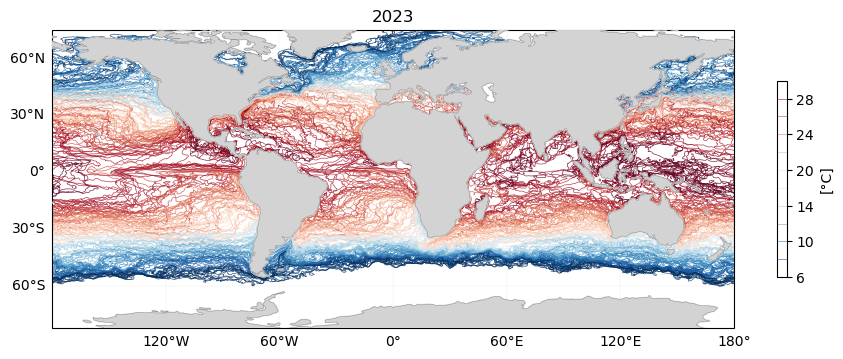

In [3]:
import cartopy.crs as ccrs
import cartopy.crs as ccrs


fig = plt.figure(figsize=(11,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines(resolution='110m',zorder=11,linewidth=.1)
ax.add_feature(cfeature.LAND,color='lightgrey',zorder=10)

gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xlocator = mticker.MaxNLocator(6)
gl.ylocator = mticker.MaxNLocator(6)
ax.set_title('2023')

year = 2023

for month in range(1,13):
    print(month)
    temp = xr.open_dataset('/srv/scratch/oceanopen/BRAN2020_files/ocean_temp_'+str(year)+'_'+str(month).zfill(2)+'_surf.nc',decode_timedelta=True).isel(nv=0,st_ocean=0,st_edges_ocean=0)
    ave_temp = np.nanmean(temp['temp'].values,axis=0)

    c=ax.contour(temp['xt_ocean'],temp['yt_ocean'],ave_temp,levels=[6,8,10,12,14,16,20,22,24,26,28,30],alpha=.8,linewidths=.5,
                 cmap='RdBu_r',transform=ccrs.PlateCarree())

fig.colorbar(c,shrink=.3,label='[°C]')
fig.savefig('map_temperature_contour2023.png',dpi=500,bbox_inches='tight')

In [18]:

from scipy.spatial import cKDTree
import numpy as np
from scipy.spatial import cKDTree
import numpy as np

from scipy.spatial import cKDTree
import numpy as np

def get_latlon_index_valid(lon_grid, lat_grid, lons_traj, lats_traj, mask=None):

    if np.nanmin(lon_grid) > 0:
        lons_traj = np.mod(lons_traj, 360)
    else:
        lon_grid = np.mod(lon_grid + 180, 360) - 180

    assert lon_grid.shape == lat_grid.shape, "lon_grid et lat_grid doivent avoir la même forme"
    if mask is not None:
        assert mask.shape == lon_grid.shape, "mask doit avoir la même forme que la grille"
        valid_mask = ~np.isnan(mask)
    else:
        valid_mask = ~np.isnan(lon_grid) & ~np.isnan(lat_grid)

    if not np.any(valid_mask):
        raise ValueError("Aucun point valide trouvé dans la grille")

    lon_valid = lon_grid[valid_mask]
    lat_valid = lat_grid[valid_mask]
    tree = cKDTree(np.column_stack((lon_valid, lat_valid)))

    lons_traj = np.asarray(lons_traj)
    lats_traj = np.asarray(lats_traj)
    mask_nan = ~np.isnan(lons_traj) & ~np.isnan(lats_traj)
    query_points = np.column_stack((lons_traj[mask_nan], lats_traj[mask_nan]))

    _, indices = tree.query(query_points)

    flat_valid_indices = np.flatnonzero(valid_mask)
    matched_flat = flat_valid_indices[indices]
    i_lat_all, i_lon_all = np.unravel_index(matched_flat, lon_grid.shape)

    i_lat_full = np.full(lons_traj.shape, np.nan)
    i_lon_full = np.full(lons_traj.shape, np.nan)
    i_lat_full[mask_nan] = i_lat_all
    i_lon_full[mask_nan] = i_lon_all

    return i_lat_full.astype(float), i_lon_full.astype(float)

def compute_temperature_sample(lons_A,lats_A,times_A):
    print('letsgo')
    years_A = pd.to_datetime(times_A).year
    min_year = np.nanmin(years_A)
    max_year = np.nanmax(years_A)
    
    temp_along_track = []

    for year in range(min_year, max_year+1):
        if year > 2009:
            
            for month in range(1,13):
                
                condi_month = np.logical_and(pd.to_datetime(times_A).year == year, pd.to_datetime(times_A).month == month)
                
                if len(condi_month[condi_month]) > 0:
                    print('in : ',year, '/', month)
                    lons_Amonth = lons_A[condi_month]
                    lats_Amonth = lats_A[condi_month]
                    times_Amonth = times_A[condi_month]
                    
                    
                    temp = xr.open_dataset('/srv/scratch/oceanopen/BRAN2020_files/ocean_temp_'+str(year)+'_'+str(month).zfill(2)+'_surf.nc',decode_timedelta=True).isel(nv=0,st_ocean=0,st_edges_ocean=0)
                    lon_temp, lat_temp = np.meshgrid(temp['xt_ocean'].values, temp['yt_ocean'].values)
                    
                    i_lat, i_lon = get_latlon_index_valid(lon_temp, lat_temp, lons_Amonth, lats_Amonth,mask=temp['temp'][0])
                    
                    idx_time = np.searchsorted(temp['Time'].values, times_Amonth)
                    
                    temp_np = temp['temp'].to_numpy()
                    for i in range(len(idx_time)):
                        temp_along_track.append(temp_np[idx_time[i],i_lat[i].astype(int),i_lon[i].astype(int)])

    return temp_along_track


In [19]:
sample_tempA = compute_temperature_sample(lons_S_A,lats_S_A,times_S_A)
sample_tempB1 = compute_temperature_sample(lons_S_B1,lats_S_B1,times_S_B1)
sample_tempB2 = compute_temperature_sample(lons_S_B2,lats_S_B2,times_S_B2)
sample_tempC1 = compute_temperature_sample(lons_S_C1,lats_S_C1,times_S_C1)
sample_tempC2 = compute_temperature_sample(lons_S_C2,lats_S_C2,times_S_C2)


letsgo
in :  2013 / 2
in :  2019 / 5
in :  2019 / 7
in :  2019 / 11
in :  2020 / 5
in :  2020 / 7
in :  2020 / 8
in :  2020 / 10
in :  2022 / 8
in :  2022 / 9
in :  2022 / 12
in :  2023 / 3
in :  2023 / 5
in :  2023 / 7
in :  2023 / 8
letsgo
in :  2011 / 11
in :  2014 / 2
in :  2018 / 11
in :  2019 / 1
in :  2019 / 4
in :  2019 / 12
in :  2020 / 11
in :  2022 / 1
in :  2022 / 4
in :  2022 / 10
in :  2022 / 11
in :  2023 / 2
in :  2023 / 3
in :  2023 / 4
in :  2023 / 6
in :  2023 / 7
in :  2023 / 8
in :  2023 / 9
in :  2023 / 10
letsgo
in :  2011 / 11
in :  2023 / 5
letsgo
in :  2018 / 3
in :  2018 / 5
in :  2019 / 4
in :  2023 / 1
in :  2023 / 7
in :  2023 / 8
in :  2023 / 10
in :  2023 / 12
letsgo
in :  2022 / 12
in :  2023 / 1
in :  2023 / 2


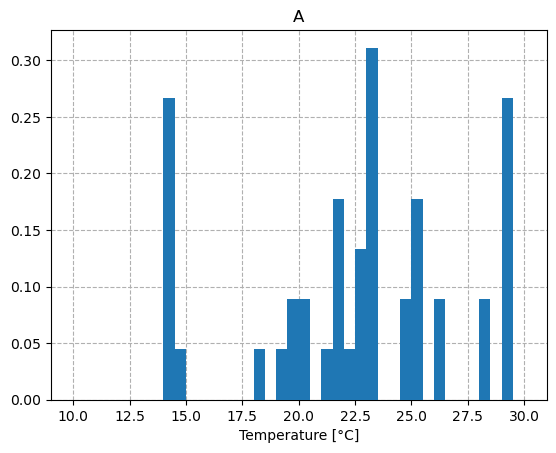

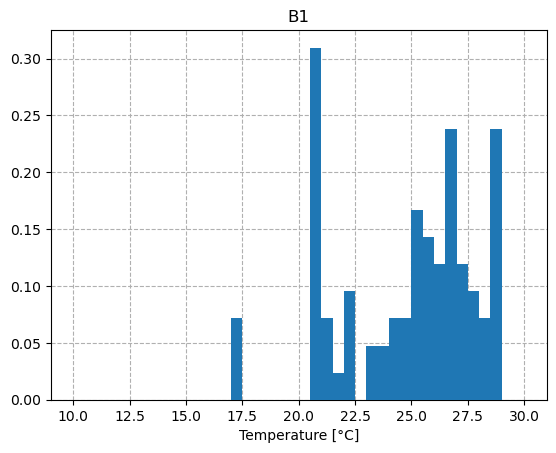

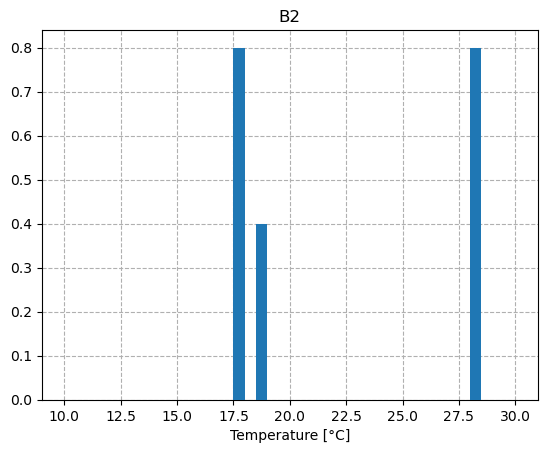

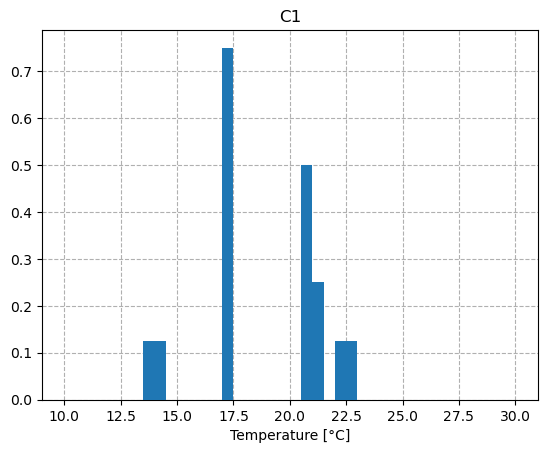

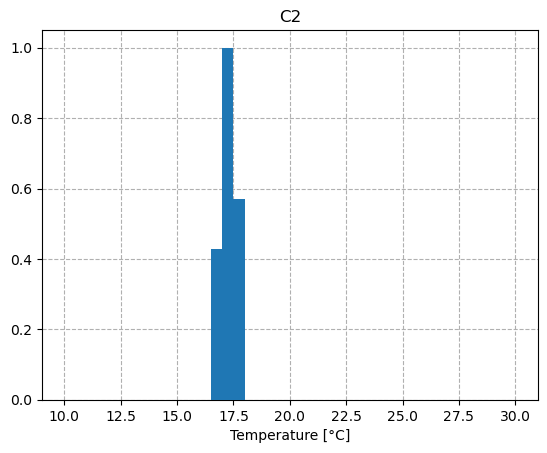

In [24]:
for lin, temp in zip(['A','B1','B2','C1','C2'], [sample_tempA, sample_tempB1,sample_tempB2, sample_tempC1, sample_tempC2]):
    
    fig, ax = plt.subplots()
    ax.set_title(lin)
    ax.grid(zorder=0,linestyle='--')
    h = ax.hist(temp, bins=40, range = [10,30], density=True, zorder=5)
    ax.set_xlabel('Temperature [°C]')

# get indexes

In [20]:
def get_latlon_index(lon_grid, lat_grid, lons_traj, lats_traj):
        
    if np.nanmin(lon_grid) > 0:
        lons_traj = np.mod(lons_traj, 360)
    else:
        lon_grid = np.mod(lon_grid + 180, 360) - 180
    
    lon_flat = lon_grid.ravel()
    lat_flat = lat_grid.ravel()
    points = np.column_stack((lon_flat, lat_flat))
    
    tree = cKDTree(points)
    
    query_points = np.column_stack((lons_traj, lats_traj))
    _, indices = tree.query(query_points)
    
    i_lat, i_lon = np.unravel_index(indices, lon_grid.shape)

    return i_lat, i_lon

In [21]:
def compute_temperature_track(lons_A,lats_A,times_A):
    print('letsgo')
    years_A = pd.to_datetime(times_A).year
    min_year = np.nanmin(years_A)
    max_year = np.nanmax(years_A)
    
    temp_along_track = []

    for year in range(min_year, max_year+1):
        if year > 2009:
            
            for month in range(1,13):
                
                condi_month = np.logical_and(pd.to_datetime(times_A).year == year, pd.to_datetime(times_A).month == month)
                
                if len(condi_month[condi_month]) > 0:
                    print('in : ',year, '/', month)
                    lons_Amonth = lons_A[condi_month]
                    lats_Amonth = lats_A[condi_month]
                    times_Amonth = times_A[condi_month]
                    
                    
                    temp = xr.open_dataset('/srv/scratch/oceanopen/BRAN2020_files/ocean_temp_'+str(year)+'_'+str(month).zfill(2)+'_surf.nc',decode_timedelta=True).isel(nv=0,st_ocean=0,st_edges_ocean=0)
                    lon_temp, lat_temp = np.meshgrid(temp['xt_ocean'].values, temp['yt_ocean'].values)
                    
                    i_lat, i_lon = get_latlon_index(lon_temp, lat_temp, lons_Amonth, lats_Amonth)
                    
                    idx_time = np.searchsorted(temp['Time'].values, times_Amonth)
                    
                    temp_np = temp['temp'].to_numpy()
                            
                    for i in range(len(idx_time)):
                        temp_along_track.append(temp_np[idx_time[i],i_lat[i],i_lon[i]])

    return temp_along_track

# temperature along track

In [22]:
tracked_tempA = compute_temperature_track(lons_A,lats_A,times_A)
tracked_tempB1 = compute_temperature_track(lons_B1,lats_B1,times_B1)


letsgo
in :  2012 / 4
in :  2012 / 5
in :  2012 / 6
in :  2012 / 7
in :  2012 / 8
in :  2012 / 9
in :  2012 / 10
in :  2012 / 11
in :  2012 / 12
in :  2013 / 1
in :  2013 / 2
in :  2013 / 3
in :  2013 / 4
in :  2018 / 5
in :  2018 / 6
in :  2018 / 7
in :  2018 / 8
in :  2018 / 9
in :  2018 / 10
in :  2018 / 11
in :  2018 / 12
in :  2019 / 1
in :  2019 / 2
in :  2019 / 3
in :  2019 / 4
in :  2019 / 5
in :  2019 / 6
in :  2019 / 7
in :  2019 / 8
in :  2019 / 9
in :  2019 / 10
in :  2019 / 11
in :  2019 / 12
in :  2020 / 1
in :  2020 / 2
in :  2020 / 3
in :  2020 / 4
in :  2020 / 5
in :  2020 / 6
in :  2020 / 7
in :  2020 / 8
in :  2021 / 3
in :  2021 / 4
in :  2021 / 5
in :  2021 / 6
in :  2021 / 7
in :  2021 / 8
in :  2021 / 9
in :  2021 / 10
in :  2021 / 11
in :  2021 / 12
in :  2022 / 1
in :  2022 / 2
in :  2022 / 3
in :  2022 / 4
in :  2022 / 5
in :  2022 / 6
in :  2022 / 7
in :  2022 / 8
in :  2022 / 9
in :  2022 / 10
in :  2022 / 11
in :  2022 / 12
in :  2023 / 1
in :  2023 / 2
in 

In [23]:

tracked_tempB2 = compute_temperature_track(lons_B2,lats_B2,times_B2)
tracked_tempC1 = compute_temperature_track(lons_C1,lats_C1,times_C1)
tracked_tempC2 = compute_temperature_track(lons_C2,lats_C2,times_C2)


letsgo
in :  2010 / 11
in :  2010 / 12
in :  2011 / 1
in :  2011 / 2
in :  2011 / 3
in :  2011 / 4
in :  2011 / 5
in :  2011 / 6
in :  2011 / 7
in :  2011 / 8
in :  2011 / 9
in :  2011 / 10
in :  2011 / 11
in :  2022 / 5
in :  2022 / 6
in :  2022 / 7
in :  2022 / 8
in :  2022 / 9
in :  2022 / 10
in :  2022 / 11
in :  2022 / 12
in :  2023 / 1
in :  2023 / 2
in :  2023 / 3
in :  2023 / 4
in :  2023 / 5
letsgo
in :  2017 / 2
in :  2017 / 3
in :  2017 / 4
in :  2017 / 5
in :  2017 / 6
in :  2017 / 7
in :  2017 / 8
in :  2017 / 9
in :  2017 / 10
in :  2017 / 11
in :  2017 / 12
in :  2018 / 1
in :  2018 / 2
in :  2018 / 3
in :  2018 / 4
in :  2018 / 5
in :  2018 / 6
in :  2018 / 7
in :  2018 / 8
in :  2018 / 9
in :  2018 / 10
in :  2018 / 11
in :  2018 / 12
in :  2019 / 1
in :  2019 / 2
in :  2019 / 3
in :  2019 / 4
in :  2022 / 1
in :  2022 / 2
in :  2022 / 3
in :  2022 / 4
in :  2022 / 5
in :  2022 / 6
in :  2022 / 7
in :  2022 / 8
in :  2022 / 9
in :  2022 / 10
in :  2022 / 11
in :  2022 

In [51]:
lineage

,sample No.,status,ID,handedness,lineage,subpopulation,vagrant,ocean,location,site,...,permit,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,1,high quality,FM-16644,right,A,A:V1,NaN,NE Atlantic,Canary Islands,La Palma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,high quality,YPM-IZ-110716,NaN,A,A:V1,NaN,NE Atlantic,Spain,Toerrgorda,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,high quality,YPM-IZ-110726,NaN,A,A:V1,NaN,NE Atlantic,Spain,Toerrgorda,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,high quality,YPM-IZ-110738,NaN,A,A:V1,NaN,NE Atlantic,Spain,Toerrgorda,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,high quality,YPM-IZ-110842,left,A,A:V1,NaN,NE Atlantic,Azores,"Porto Pim beach, Faial Island, Azores",...,"Secretaria Regional do Mar, Ciência e Tecnolog...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,159,excluded,YPM-IZ-110827,NaN,NaN,NaN,NaN,SE Pacific,Chile,"Morrillos, Coquimbo, Chile",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,160,excluded,YPM-IZ-110879,NaN,NaN,NaN,NaN,Gulf of California,Mexico,Gulf of California,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160,161,excluded,YPM-IZ-110973,right,NaN,NaN,NaN,NE Atlantic,Ireland,"Near Dooley's Seafood & Steak House, Watervill...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161,162,excluded,YPM-IZ-111015,NaN,NaN,NaN,NaN,NW Atlantic,Bermuda,NaN,...,Bermuda Special Permit no. SP200501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
lineage['lineage']

0        A
1        A
2        A
3        A
4        A
      ... 
158    NaN
159    NaN
160    NaN
161    NaN
162    NaN
Name: lineage, Length: 163, dtype: object

In [72]:
len(lineage['status'][np.logical_or(lineage['status']=='excluded',date_pd < pd.to_datetime(datetime.datetime(2024,1,1)))]) 

142

In [73]:
from collections import Counter

from collections import Counter

# Zip all four fields into one record
records = list(zip(lineage['longitue'].values, lineage['latitude'].values, lineage['lineage'].values, lineage['handedness'].values, lineage['date_collected'].values))

# Count how many times each full record appears
counts = Counter(records)

# Count how many extra samples there are (beyond the first occurrence)
extra_samples = sum(v - 1 for v in counts.values() if v > 1)

print(f"Number of extra samples with same lon, lat, species, and date: {extra_samples}")


Number of extra samples with same lon, lat, species, and date: 48


In [71]:
import datetime
date_pd = pd.to_datetime(lineage['date_collected'])
len(date_pd[date_pd < pd.to_datetime(datetime.datetime(2024,1,1))])

/scratch/pbs.6614217.kman.restech.unsw.edu.au/ipykernel_1101656/2311123573.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  date_pd = pd.to_datetime(lineage['date_collected'])


142

In [50]:
print(np.nanmin(pd.to_datetime(lineage['date_collected'])))
print(np.nanmax(pd.to_datetime(lineage['date_collected'])))

2006-06-09T00:00:00.000000000
2024-06-02T00:00:00.000000000


/scratch/pbs.6614217.kman.restech.unsw.edu.au/ipykernel_1101656/1771481416.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  print(np.nanmin(pd.to_datetime(lineage['date_collected'])))
/scratch/pbs.6614217.kman.restech.unsw.edu.au/ipykernel_1101656/1771481416.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  print(np.nanmax(pd.to_datetime(lineage['date_collected'])))


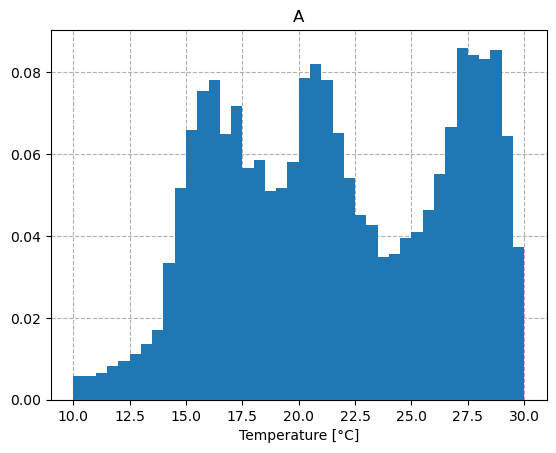

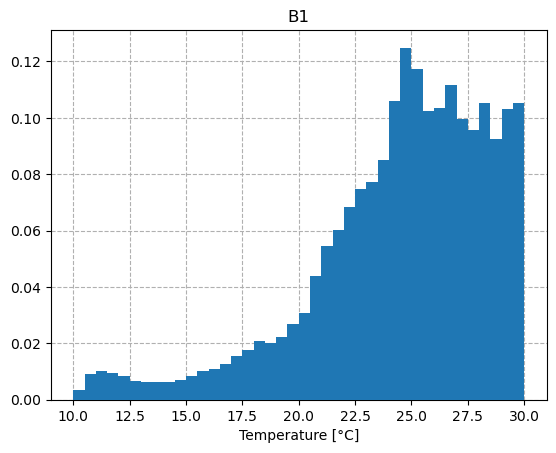

In [29]:
for lin, temp in zip(['A','B1'], [tracked_tempA, tracked_tempB1]):
    fig, ax = plt.subplots()
    ax.set_title(lin)
    ax.grid(zorder=0,linestyle='--')
    h = ax.hist(temp,bins=40,range = [10,30],density=True,zorder=5)
    ax.set_xlabel('Temperature [°C]')

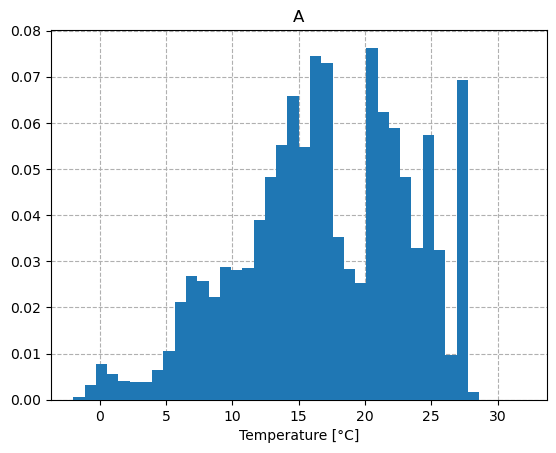

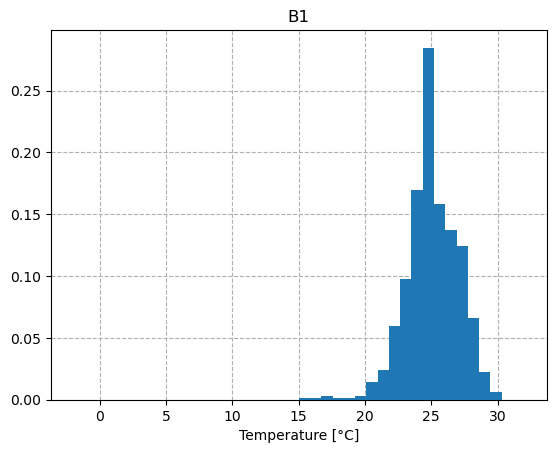

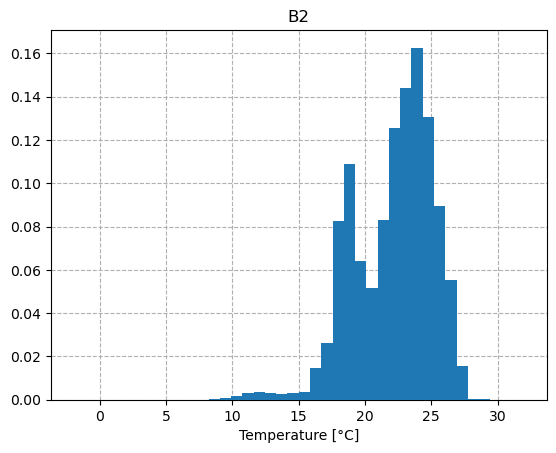

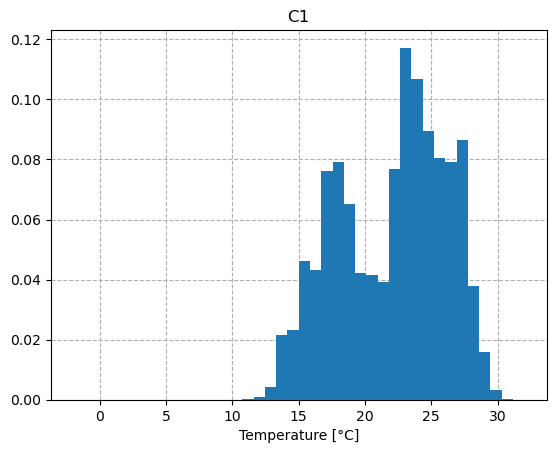

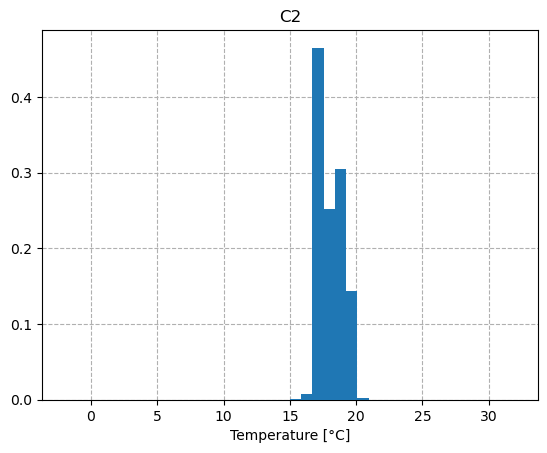

In [82]:
for lin, temp in zip(['A','B1','B2','C1','C2'], [tracked_tempA, tracked_tempB1, tracked_tempB2, tracked_tempC1, tracked_tempC2]):
    fig, ax = plt.subplots()
    ax.set_title(lin)
    ax.grid(zorder=0,linestyle='--')
    h = ax.hist(temp,bins=40,range = [-2,32],density=True,zorder=5)
    ax.set_xlabel('Temperature [°C]')

In [24]:
print(np.nanmin(tracked_tempA), np.nanmax(tracked_tempA))
print(np.nanmin(tracked_tempB1), np.nanmax(tracked_tempB1))
print(np.nanmin(tracked_tempB2), np.nanmax(tracked_tempB2))
print(np.nanmin(tracked_tempC1), np.nanmax(tracked_tempC1))
print(np.nanmin(tracked_tempC2), np.nanmax(tracked_tempC2))

-1.8364563 31.868347
1.3776093 32.023987
8.046967 31.541489
1.6110687 31.26912
0.7316742 30.841095


In [132]:
print(np.nanmin(tracked_tempA), np.nanmax(tracked_tempA))
print(np.nanmin(tracked_tempB1), np.nanmax(tracked_tempB1))
print(np.nanmin(tracked_tempB2), np.nanmax(tracked_tempB2))
print(np.nanmin(tracked_tempC1), np.nanmax(tracked_tempC1))
print(np.nanmin(tracked_tempC2), np.nanmax(tracked_tempC2))

-1.8364563 31.868347
1.3776093 32.023987
6.054718 31.603745
1.6110687 31.26912
0.7316742 30.841095


In [25]:
sstA = np.array(tracked_tempA)
sstB1 = np.array(tracked_tempB1)
sstB2 = np.array(tracked_tempB2)
sstC1 = np.array(tracked_tempC1)
sstC2 = np.array(tracked_tempC2)


In [26]:
print("A", np.percentile(sstA[~np.isnan(sstA)], 10),  np.percentile(sstA[~np.isnan(sstA)], 90))
print("B1", np.percentile(sstB1[~np.isnan(sstB1)], 10),  np.percentile(sstB1[~np.isnan(sstB1)], 90))
print("B2", np.percentile(sstB2[~np.isnan(sstB2)], 10),  np.percentile(sstB2[~np.isnan(sstB2)], 90))
print("C1", np.percentile(sstC1[~np.isnan(sstC1)], 10),  np.percentile(sstC1[~np.isnan(sstC1)], 90))
print("C2", np.percentile(sstC2[~np.isnan(sstC2)], 10),  np.percentile(sstC2[~np.isnan(sstC2)], 90))


A 14.825286865234375 28.623153686523438
B1 18.15606689453125 28.82550048828125
B2 24.1328125 29.066741943359375
C1 12.381668090820312 27.02001953125
C2 11.704605102539062 19.152191162109375


In [29]:
print("A", np.percentile(sstA[~np.isnan(sstA)], 10),  np.percentile(sstA[~np.isnan(sstA)], 90))
print("B1", np.percentile(sstB1[~np.isnan(sstB1)], 10),  np.percentile(sstB1[~np.isnan(sstB1)], 90))
print("B2", np.percentile(sstB2[~np.isnan(sstB2)], 10),  np.percentile(sstB2[~np.isnan(sstB2)], 90))
print("C1", np.percentile(sstC1[~np.isnan(sstC1)], 10),  np.percentile(sstC1[~np.isnan(sstC1)], 90))
print("C2", np.percentile(sstC2[~np.isnan(sstC2)], 10),  np.percentile(sstC2[~np.isnan(sstC2)], 90))


A 14.786376953125 28.506423950195312
B1 19.15997314453125 29.214599609375
B2 24.358505249023438 29.0589599609375
C1 12.607345581054688 27.409133911132812
C2 11.299942016601562 18.8331298828125


In [42]:
print("A", np.nanmean(sstA))
print("B1", np.nanmean(sstB1))
print("B2", np.nanmean(sstB2))
print("C1", np.nanmean(sstC1))
print("C2", np.nanmean(sstC2))


A 21.604332
B1 23.997606
B2 26.96916
C1 20.34912
C2 15.488793


In [43]:
print("A", np.nanmedian(sstA))
print("B1", np.nanmedian(sstB1))
print("B2", np.nanmedian(sstB2))
print("C1", np.nanmedian(sstC1))
print("C2", np.nanmedian(sstC2))


A 21.665848
B1 24.78653
B2 27.697067
C1 21.10553
C2 15.300003


/scratch/pbs.6542946.kman.restech.unsw.edu.au/ipykernel_2598703/4058490527.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")


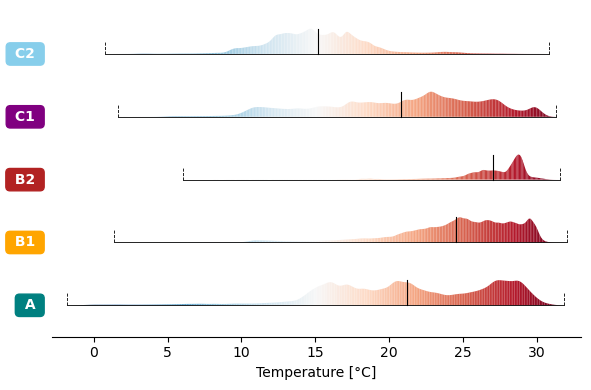

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Polygon
import matplotlib.cm as cm
import matplotlib.colors as mcolors

list_sst = [sstA[~np.isnan(sstA)],
            sstB1[~np.isnan(sstB1)],
            sstB2[~np.isnan(sstB2)],
            sstC1[~np.isnan(sstC1)],
            sstC2[~np.isnan(sstC2)]]

labels = ['A', 'B1', 'B2', 'C1', 'C2']

all_data = np.concatenate(list_sst)
vmin, vmax = np.min(all_data), np.max(all_data)
cmap = cm.get_cmap("RdBu_r")
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlabel("Temperature [°C]")
ax.set_yticks([])
#ax.set_yticklabels(labels)
ax.set_xlim(vmin - 1, vmax + 1)
ax.set_ylim(-.5, len(list_sst)-.3)

# Plot each violin (half top only)
for idx, data in enumerate(list_sst):
    kde = gaussian_kde(data)
    x = np.linspace(np.min(data), np.max(data), 300)
    y = kde(x)
    y = y / y.max() * 0.4  # control violin width

    for i in range(len(x) - 1):
        verts = [
            [x[i], idx],                   # bottom
            [x[i], y[i] + idx],            # top left
            [x[i + 1], y[i + 1] + idx],    # top right
            [x[i + 1], idx],               # bottom
        ]
        color = cmap(norm((x[i] + x[i + 1]) / 2))
        patch = Polygon(verts, facecolor=color, edgecolor='none', linewidth=0)
        ax.add_patch(patch)

    # Horizontal min-max line
    min_val = np.min(data)
    max_val = np.max(data)
    ax.plot([min_val, max_val], [idx, idx], color='k', lw=.6, zorder=10)

    # Define your desired percentiles
    #p_low, p_high = 1, 99  # or 10 and 90
    
    # Compute the percentiles
    #low_val = np.percentile(data, p_low)
    #high_val = np.percentile(data, p_high)
    
    # Plot the horizontal line between these percentiles
    #ax.plot([low_val, high_val], [idx, idx], color='k', lw=0.6, zorder=10)
    
        
    # Mean vertical line
    mean = np.mean(data)
    ax.plot([mean, mean], [idx, idx + 0.4], color='k', lw=.8, zorder=11)

    # Min/Max lines
    min_val = np.min(data)
    max_val = np.max(data)
    ax.plot([min_val, min_val], [idx, idx + 0.2], color='k', lw=0.6, linestyle='--')
    ax.plot([max_val, max_val], [idx, idx + 0.2], color='k', lw=0.6, linestyle='--')
label_colors = ['skyblue', 'purple', 'firebrick', 'orange', 'teal'][::-1]
label_names = [' A ', ' B1 ', ' B2 ', ' C1 ', ' C2 ']

for idx, (label, color) in enumerate(zip(label_names, label_colors)):
    ax.text(vmin - 1.8, idx, label,
            fontsize=10,
            fontweight='bold',
            color='white',
            va='center',
            ha='right',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor=color,
                edgecolor=color,
                alpha=1
            ))

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig("violin_half_gradient_minmaxlinenospine_ALLYEARS.png", dpi=500, bbox_inches='tight')
plt.show()


/scratch/pbs.6614217.kman.restech.unsw.edu.au/ipykernel_1101656/2778320695.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")


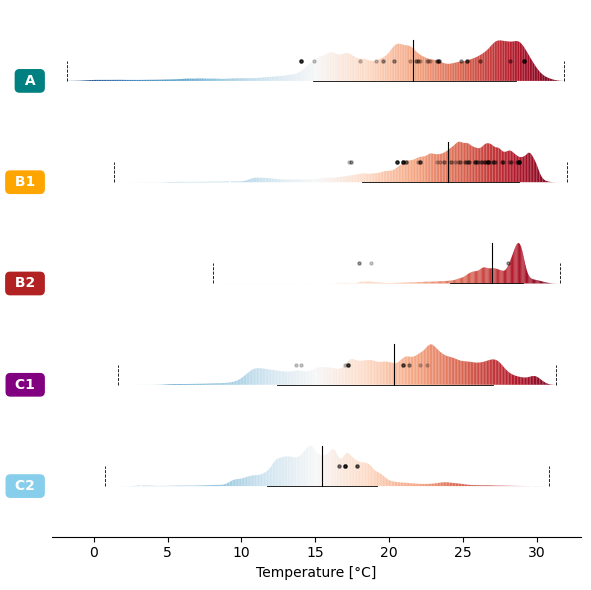

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Polygon
import matplotlib.cm as cm
import matplotlib.colors as mcolors

list_sst = [sstA[~np.isnan(sstA)],
            sstB1[~np.isnan(sstB1)],
            sstB2[~np.isnan(sstB2)],
            sstC1[~np.isnan(sstC1)],
            sstC2[~np.isnan(sstC2)]][::-1]

list_scatter_sample = [sample_tempA,
                       sample_tempB1,
                       sample_tempB2,
                       sample_tempC1,
                       sample_tempC2][::-1]

labels = ['A', 'B1', 'B2', 'C1', 'C2']

all_data = np.concatenate(list_sst)
vmin, vmax = np.min(all_data), np.max(all_data)
cmap = cm.get_cmap("RdBu_r")
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlabel("Temperature [°C]")
ax.set_yticks([])

ax.set_xlim(vmin - 1, vmax + 1)
ax.set_ylim(-.5, len(list_sst)-.3)


for idx, data in enumerate(list_sst):
    kde = gaussian_kde(data)
    x = np.linspace(np.min(data), np.max(data), 300)
    y = kde(x)
    y = y / y.max() * 0.4  # control violin width

    for i in range(len(x) - 1):
        verts = [
            [x[i], idx],                   # bottom
            [x[i], y[i] + idx],            # top left
            [x[i + 1], y[i + 1] + idx],    # top right
            [x[i + 1], idx],               # bottom
        ]
        color = cmap(norm((x[i] + x[i + 1]) / 2))
        patch = Polygon(verts, facecolor=color, edgecolor='none', linewidth=0)
        ax.add_patch(patch)

    # Horizontal min-max line
    min_val = np.min(data)
    max_val = np.max(data)
    #ax.plot([min_val, max_val], [idx, idx], color='k', lw=.6, zorder=10)

    # Define your desired percentiles
    p_low, p_high = 10, 90  # or 10 and 90
    
    # Compute the percentiles
    low_val = np.percentile(data, p_low)
    high_val = np.percentile(data, p_high)
    
    # Plot the horizontal line between these percentiles
    ax.plot([low_val, high_val], [idx, idx], color='k', lw=0.6, zorder=10)
    
    
    # Mean vertical line
    mean = np.mean(data)
    ax.plot([mean, mean], [idx, idx + 0.4], color='k', lw=.8, zorder=11)

    # Min/Max lines
    min_val = np.min(data)
    max_val = np.max(data)
    ax.plot([min_val, min_val], [idx, idx + 0.2], color='k', lw=0.6, linestyle='--')
    ax.plot([max_val, max_val], [idx, idx + 0.2], color='k', lw=0.6, linestyle='--')


ax.scatter(sample_tempA,4.2*np.ones(np.array(sample_tempA).shape),s=5,c='k',alpha=.2)
ax.scatter(sample_tempB1,3.2*np.ones(np.array(sample_tempB1).shape),s=5,c='k',alpha=.2)
ax.scatter(sample_tempB2,2.2*np.ones(np.array(sample_tempB2).shape),s=5,c='k',alpha=.2)
ax.scatter(sample_tempC1,1.2*np.ones(np.array(sample_tempC1).shape),s=5,c='k',alpha=.2)
ax.scatter(sample_tempC2,0.2*np.ones(np.array(sample_tempC2).shape),s=5,c='k',alpha=.2)


label_colors = ['skyblue', 'purple', 'firebrick', 'orange', 'teal']
label_names = [' A ', ' B1 ', ' B2 ', ' C1 ', ' C2 '][::-1]
    
for idx, (label, color) in enumerate(zip(label_names, label_colors)):
    ax.text(vmin - 1.8, idx, label,
            fontsize=10,
            fontweight='bold',
            color='white',
            va='center',
            ha='right',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor=color,
                edgecolor=color,
                alpha=1
            ))

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig("violin_ALLYEARS1000TRAJCORRECTED.png", dpi=500, bbox_inches='tight')


/scratch/pbs.6542946.kman.restech.unsw.edu.au/ipykernel_2598703/3346694868.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")


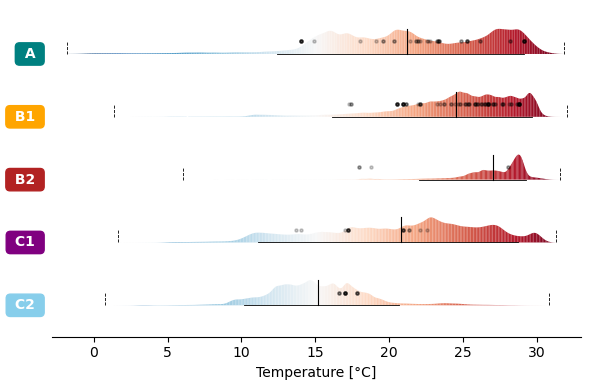

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Polygon
import matplotlib.cm as cm
import matplotlib.colors as mcolors

list_sst = [sstA[~np.isnan(sstA)],
            sstB1[~np.isnan(sstB1)],
            sstB2[~np.isnan(sstB2)],
            sstC1[~np.isnan(sstC1)],
            sstC2[~np.isnan(sstC2)]][::-1]

list_scatter_sample = [sample_tempA,
                       sample_tempB1,
                       sample_tempB2,
                       sample_tempC1,
                       sample_tempC2][::-1]

labels = ['A', 'B1', 'B2', 'C1', 'C2']

all_data = np.concatenate(list_sst)
vmin, vmax = np.min(all_data), np.max(all_data)
cmap = cm.get_cmap("RdBu_r")
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlabel("Temperature [°C]")
ax.set_yticks([])

ax.set_xlim(vmin - 1, vmax + 1)
ax.set_ylim(-.5, len(list_sst)-.3)


for idx, data in enumerate(list_sst):
    kde = gaussian_kde(data)
    x = np.linspace(np.min(data), np.max(data), 300)
    y = kde(x)
    y = y / y.max() * 0.4  # control violin width

    for i in range(len(x) - 1):
        verts = [
            [x[i], idx],                   # bottom
            [x[i], y[i] + idx],            # top left
            [x[i + 1], y[i + 1] + idx],    # top right
            [x[i + 1], idx],               # bottom
        ]
        color = cmap(norm((x[i] + x[i + 1]) / 2))
        patch = Polygon(verts, facecolor=color, edgecolor='none', linewidth=0)
        ax.add_patch(patch)

    # Horizontal min-max line
    min_val = np.min(data)
    max_val = np.max(data)
    #ax.plot([min_val, max_val], [idx, idx], color='k', lw=.6, zorder=10)

    # Define your desired percentiles
    p_low, p_high = 5, 95  # or 10 and 90
    
    # Compute the percentiles
    low_val = np.percentile(data, p_low)
    high_val = np.percentile(data, p_high)
    
    # Plot the horizontal line between these percentiles
    ax.plot([low_val, high_val], [idx, idx], color='k', lw=0.6, zorder=10)
    
    
    # Mean vertical line
    mean = np.mean(data)
    ax.plot([mean, mean], [idx, idx + 0.4], color='k', lw=.8, zorder=11)

    # Min/Max lines
    min_val = np.min(data)
    max_val = np.max(data)
    ax.plot([min_val, min_val], [idx, idx + 0.2], color='k', lw=0.6, linestyle='--')
    ax.plot([max_val, max_val], [idx, idx + 0.2], color='k', lw=0.6, linestyle='--')


ax.scatter(sample_tempA,4.2*np.ones(np.array(sample_tempA).shape),s=5,c='k',alpha=.2)
ax.scatter(sample_tempB1,3.2*np.ones(np.array(sample_tempB1).shape),s=5,c='k',alpha=.2)
ax.scatter(sample_tempB2,2.2*np.ones(np.array(sample_tempB2).shape),s=5,c='k',alpha=.2)
ax.scatter(sample_tempC1,1.2*np.ones(np.array(sample_tempC1).shape),s=5,c='k',alpha=.2)
ax.scatter(sample_tempC2,0.2*np.ones(np.array(sample_tempC2).shape),s=5,c='k',alpha=.2)


label_colors = ['skyblue', 'purple', 'firebrick', 'orange', 'teal']
label_names = [' A ', ' B1 ', ' B2 ', ' C1 ', ' C2 '][::-1]
    
for idx, (label, color) in enumerate(zip(label_names, label_colors)):
    ax.text(vmin - 1.8, idx, label,
            fontsize=10,
            fontweight='bold',
            color='white',
            va='center',
            ha='right',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor=color,
                edgecolor=color,
                alpha=1
            ))

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig("violin_ALLYEARS_5_95.png", dpi=500, bbox_inches='tight')
